<hr>

<center>
    Class: Machine Learning in Computational Biology <br>
    Program: Data Science and Information Technologies <br>
    Name: Aris <br>
    Las name: Podotas <br>
    ID: 7115152400040 <br>
    Assignment: 1 <br>
</center>

<hr>

In [1]:
# This will be very similar to the model analysis file
# Importing libraries
import matplotlib.pyplot as plt
import numpy as np
import os # I might not use this
import pandas as pd
from sklearn.linear_model import BayesianRidge, ElasticNet
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, median_absolute_error, r2_score # spoilers
from sklearn.svm import SVR
import sys
sys.path.append('../src/')
import functions as utils


Function 'dataSplit' executed in 0.0058 seconds
Function 'dataSplit' executed in 0.0000 seconds
Function 'isolator' executed in 0.0000 seconds
Function 'isolator' executed in 0.0000 seconds


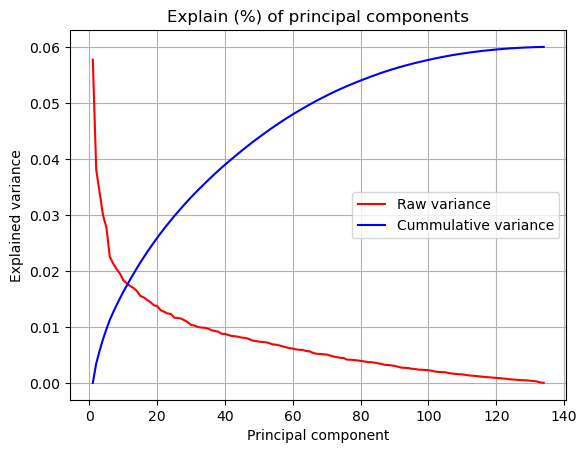

Function 'searchPca' executed in 0.2506 seconds
Function 'fitPca' executed in 0.0062 seconds
Function 'applyPca' executed in 0.0021 seconds
Function 'applyPca' executed in 0.0080 seconds


In [2]:
root = '../data/'
dev = pd.read_csv(root + 'development_final_data.csv')
val = pd.read_csv(root + 'evaluation_final_data.csv')
del root
devData, devMeta = utils.dataSplit(dev)
valData, valMeta = utils.dataSplit(val)
train, preds = utils.isolator(devData)
validation, truth = utils.isolator(valData)
utils.searchPca(train)
holder = utils.fitPca(train, 95)
trainPca = utils.applyPca(train, holder)
valPca = utils.applyPca(validation, holder)
del holder


In [3]:
trainPca.head()


,0,1,2,3,4,5,6,7,8,9,...,85,86,87,88,89,90,91,92,93,94
0,-1.849089,-0.140920,-1.266297,-0.145266,-0.301463,-0.185271,0.213756,-0.517308,-0.048592,-0.344645,...,0.123970,0.170621,-0.354964,0.045266,-0.038382,-0.016285,-0.029371,-0.259434,-0.052854,-0.128872
1,3.043090,10.763641,2.874763,-4.693270,-0.041211,-0.084973,-1.329089,-2.964214,1.211787,-1.868861,...,0.853981,0.112889,-0.410547,0.622230,0.798453,0.214674,-0.408864,1.077974,-0.788656,-0.528223
2,-2.403592,0.270338,-1.193480,-0.320505,-0.624223,-0.278452,-0.283442,-0.085687,-0.253455,0.504979,...,0.019852,0.268311,-0.114725,-0.016287,-0.248290,0.059599,0.161361,0.267282,0.077818,-0.054439
3,0.610512,-0.157055,0.616014,1.940658,-0.451681,-1.180577,-0.962582,0.257780,0.158454,0.672316,...,-0.709676,-0.949189,-0.670401,0.154740,-0.350549,2.171668,-0.275381,-0.637749,-0.614822,-0.220837
4,2.125645,-3.238797,-0.077841,-1.307018,-0.529641,-0.873104,-0.526120,-0.087158,-1.768089,0.716517,...,0.481511,-0.104006,0.394107,-0.646282,-1.188266,0.232789,-0.613627,1.345919,-1.918396,0.882115


In [4]:
valPca.head()


,0,1,2,3,4,5,6,7,8,9,...,85,86,87,88,89,90,91,92,93,94
0,-1.449254,-0.118120,0.192261,-0.252096,0.020092,0.036432,0.208829,-0.453389,-1.233135,0.017618,...,0.546344,-0.060728,0.075999,-0.025645,-0.040778,0.419661,-0.222014,0.354806,-0.048871,-0.338722
1,-1.365614,-0.071044,-1.520152,-0.453508,-1.362667,-1.252783,-0.540205,0.147210,0.239817,-0.305829,...,0.017891,-0.023925,-0.081162,-0.036696,-0.105939,0.014606,-0.020344,-0.023393,-0.028802,-0.063492
2,-0.930474,0.309158,-1.145262,-0.074573,-0.112228,0.298727,4.198898,2.916844,-0.003848,0.628372,...,0.058915,0.339861,-0.241391,0.430265,-0.093608,-0.437303,0.039219,-0.249777,-0.266965,-0.178463
3,-1.370224,-0.071494,-0.995597,-0.402944,-1.396126,-1.222569,-0.405407,0.131836,-0.026556,-0.321738,...,0.022721,-0.016732,-0.139483,-0.140854,-0.036689,0.046905,-0.016968,0.061309,-0.026978,-0.100179
4,-1.365614,-0.071044,-1.520152,-0.453508,-1.362667,-1.252783,-0.540205,0.147210,0.239817,-0.305829,...,0.017891,-0.023925,-0.081162,-0.036696,-0.105939,0.014606,-0.020344,-0.023393,-0.028802,-0.063492


In [5]:
devPca = trainPca.copy()
wholeValPca = valPca.copy()
devPca.insert(0, 'BMI', preds)
wholeValPca.insert(0, 'BMI', truth)
devPca.head()


,BMI,0,1,2,3,4,5,6,7,8,...,85,86,87,88,89,90,91,92,93,94
0,19.01,-1.849089,-0.140920,-1.266297,-0.145266,-0.301463,-0.185271,0.213756,-0.517308,-0.048592,...,0.123970,0.170621,-0.354964,0.045266,-0.038382,-0.016285,-0.029371,-0.259434,-0.052854,-0.128872
1,23.50,3.043090,10.763641,2.874763,-4.693270,-0.041211,-0.084973,-1.329089,-2.964214,1.211787,...,0.853981,0.112889,-0.410547,0.622230,0.798453,0.214674,-0.408864,1.077974,-0.788656,-0.528223
2,25.80,-2.403592,0.270338,-1.193480,-0.320505,-0.624223,-0.278452,-0.283442,-0.085687,-0.253455,...,0.019852,0.268311,-0.114725,-0.016287,-0.248290,0.059599,0.161361,0.267282,0.077818,-0.054439
3,23.49,0.610512,-0.157055,0.616014,1.940658,-0.451681,-1.180577,-0.962582,0.257780,0.158454,...,-0.709676,-0.949189,-0.670401,0.154740,-0.350549,2.171668,-0.275381,-0.637749,-0.614822,-0.220837
4,22.60,2.125645,-3.238797,-0.077841,-1.307018,-0.529641,-0.873104,-0.526120,-0.087158,-1.768089,...,0.481511,-0.104006,0.394107,-0.646282,-1.188266,0.232789,-0.613627,1.345919,-1.918396,0.882115


C:\Users\aPodo\Documents\Assignment-1-MLICB\notebooks\../src\functions.py:702: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  study = optuna.create_study(sampler=optuna.samplers.GPSampler(), direction='maximize')
[I 2025-03-28 15:57:55,870] A new study created in memory with name: no-name-d88fd7f5-63bb-4280-9aec-a453be05a324
[I 2025-03-28 15:57:55,884] Trial 0 finished with value: 4.245514243926403 and parameters: {'alpha_1': 3.695705472721643e-05, 'alpha_2': 2.4750281321119237e-05, 'lambda_1': 7.919624145506713e-05, 'lambda_2': 2.957311450667237e-05}. Best is trial 0 with value: 4.245514243926403.
[I 2025-03-28 15:57:55,898] Trial 1 finished with value: 4.245499995558106 and parameters: {'alpha_1': 4.883065826452975e-05, 'alpha_2': 2.7573460140077545e-05, 'lambda_1': 2.347479610291086e-05, 'lambda_2': 1.0653884879540784e-05}. Best is trial 0 with value: 4.245514243926403.
[I 2025-03-28 15:57:55,916] Trial 2 finished wi

Function 'optimizeRidge' executed in 20.1764 seconds


[I 2025-03-28 15:58:19,799] Trial 0 finished with value: 4.704846719231522 and parameters: {'C': 9.98398192249017, 'gamma': 'auto', 'epsilon': 0.051122537877363296, 'kernel': 'linear', 'degree': 4, 'coef0': 0.24822222051233978}. Best is trial 0 with value: 4.704846719231522.
[I 2025-03-28 15:58:19,822] Trial 1 finished with value: 4.088370921715299 and parameters: {'C': 4.961715547605761, 'gamma': 'auto', 'epsilon': 0.8433444766287433, 'kernel': 'rbf', 'degree': 4, 'coef0': 0.549995121096206}. Best is trial 0 with value: 4.704846719231522.
[I 2025-03-28 15:58:19,836] Trial 2 finished with value: 13.797838007850036 and parameters: {'C': 9.039336029355903, 'gamma': 'auto', 'epsilon': 0.4543489929197771, 'kernel': 'poly', 'degree': 2, 'coef0': 0.020862010488776894}. Best is trial 2 with value: 13.797838007850036.
[I 2025-03-28 15:58:19,864] Trial 3 finished with value: 24.898178298294603 and parameters: {'C': 5.067742748726689, 'gamma': 'auto', 'epsilon': 0.13700640868610311, 'kernel': 'p

Function 'optimizeSVR' executed in 42.5155 seconds


[I 2025-03-28 15:58:58,800] Trial 10 finished with value: 4.461470011957763 and parameters: {'alpha': 0.1, 'l1_ratio': 0.2923550321881949}. Best is trial 10 with value: 4.461470011957763.
[I 2025-03-28 15:58:58,914] Trial 11 finished with value: 4.509765001344444 and parameters: {'alpha': 0.1, 'l1_ratio': 0.04379860649970896}. Best is trial 11 with value: 4.509765001344444.
[I 2025-03-28 15:58:59,003] Trial 12 finished with value: 4.497413191153295 and parameters: {'alpha': 0.1, 'l1_ratio': 0.10444183759957758}. Best is trial 11 with value: 4.509765001344444.
C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.978e+03, tolerance: 8.640e-01 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers

Function 'optimizeNet' executed in 16.2497 seconds
Function 'regressions' executed in 0.1077 seconds
Function 'applyMetrics' executed in 0.0250 seconds


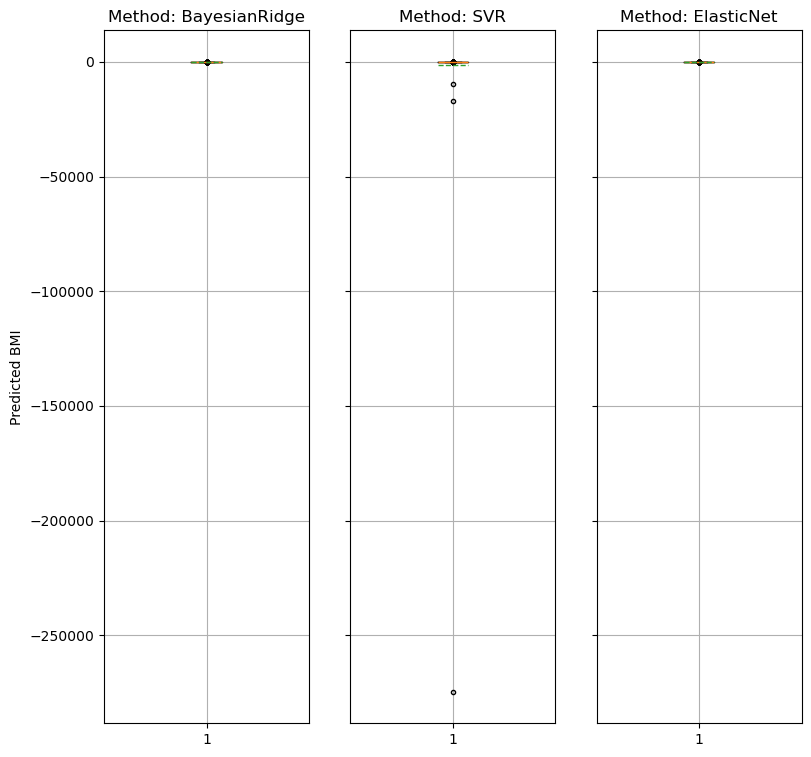

Function 'visualisePredictions' executed in 0.2091 seconds


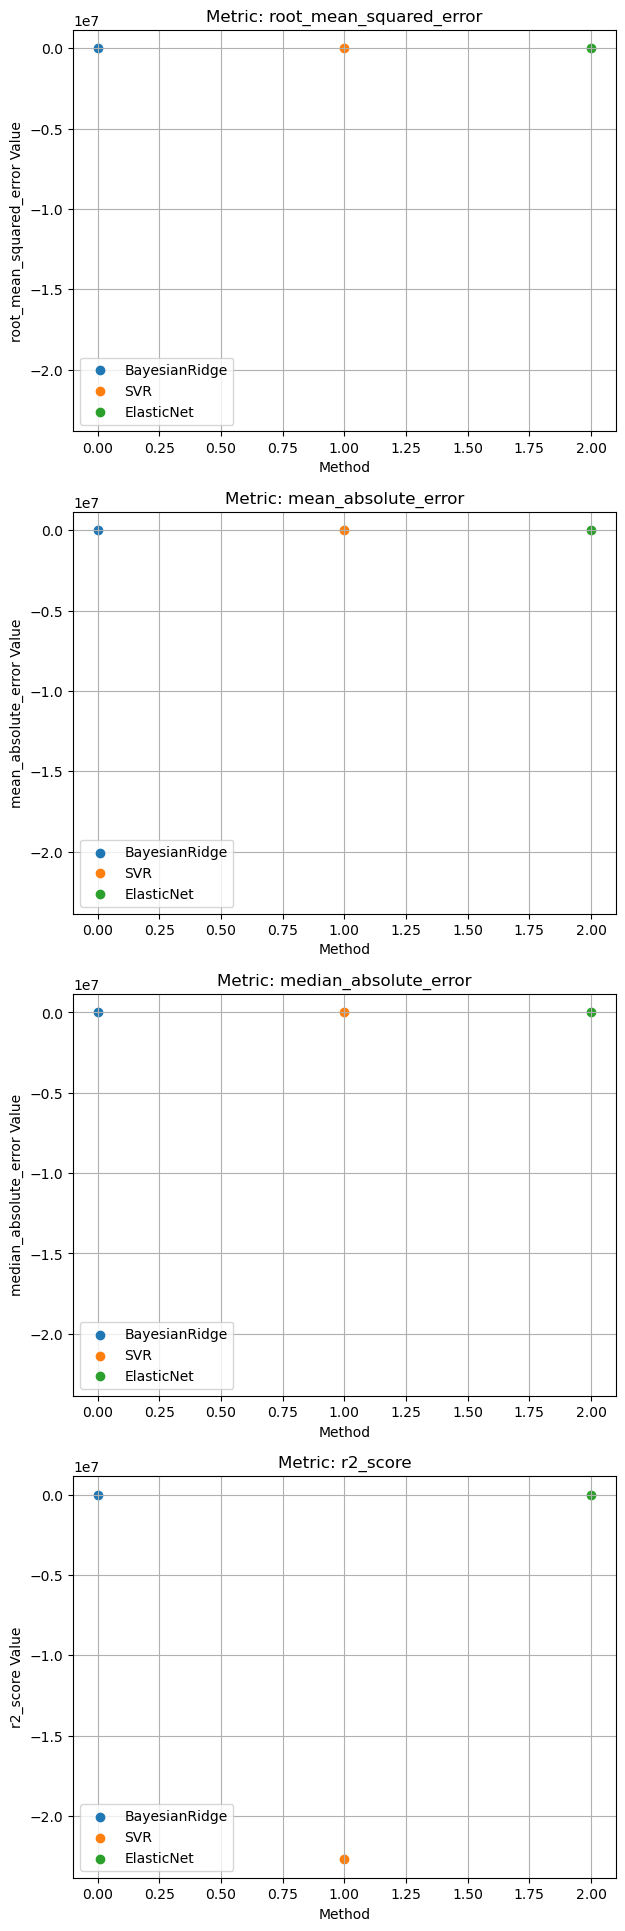

Function 'visualiseEvaluations' executed in 0.6566 seconds


In [7]:
ridgeTuned = utils.optimizeRidge(root_mean_squared_error, trainPca, preds, valPca, truth, extra = True)
svrTuned = utils.optimizeSVR(root_mean_squared_error, trainPca, preds, valPca, truth, extra = True)
netTuned = utils.optimizeNet(root_mean_squared_error, trainPca, preds, valPca, truth, extra = True)
options = np.array([BayesianRidge, SVR, ElasticNet])
metrics = np.array([root_mean_squared_error, mean_absolute_error, median_absolute_error, r2_score])
arguments = [ridgeTuned, svrTuned, netTuned]

predictions = utils.regressions(options, trainPca, preds, valPca, arguments = arguments)
scores = utils.applyMetrics(metrics, options, truth, predictions)
utils.visualisePredictions(predictions, options, verbose = False)
utils.visualiseEvaluations(scores, options, metrics, verbose = False)

<hr>

# Results

These results are primarily skewed for viewing properly by the results of the support vector that has a uniquely bad predicted outlier. It is interesting to note that in the whole exercise thus far the tendency is to predict lower rather tahn higher.

# Comparison with previous

This parameter in optuna has actually performed worse than the default option (```GPSampler()```, ```BaseSampler()```). Specifically the support vector has output a worse total distribution and the ```r2_score``` seem to have been significantly altered but only for the support vector. The other methods seem to have maintained the same metrics and this hold true for the support vector too despite the significant outlier introduced.

<hr>